# Sparkles training console (simple)

Interactive wrapper around the same Python APIs as the CLI. Edit **parameters** below, run **dry-run**, then flip **`DO_TRAIN`** when ready.

**Setup** (once, from repo root):

```bash
pip install -e ".[dev,notebook,ml]"   # ml = XGBoost
jupyter notebook notebooks/sparkles_train_console.ipynb
```

After `pip install` or pulling new code: **Kernel → Restart** (Jupyter caches old `sparkles` imports).

Cell 1 prints `Phase G1 schema: OK` — if it says **MISSING**, reinstall and restart the kernel.

Prerequisites on disk: `sparkles ingest` and `sparkles label` for your config (same as CLI).

In [139]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

# Repo root (parent of notebooks/)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "sparkles").is_dir():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "sparkles").is_dir():
    raise RuntimeError("Open this notebook from the Sparkles repo root or notebooks/ folder")

import os
os.chdir(REPO_ROOT)

# Prefer repo source over a stale site-packages install (then restart kernel once).
_repo_src = str((REPO_ROOT / "sparkles").resolve().parent)
if _repo_src not in sys.path:
    sys.path.insert(0, _repo_src)

from sparkles.env import load_dotenv
load_dotenv()

import sparkles
from sparkles.config.schema import FeatureConfig

# If you added G1 features in OVERRIDES but this fails, restart the kernel after:
#   pip install -e ".[dev,notebook,ml]"
_g1_fields = ("returns_multi_horizon", "realized_vol_multi", "range_vol_multi")
_has_g1_schema = all(f in FeatureConfig.model_fields for f in _g1_fields)

print("Working directory:", REPO_ROOT.resolve())
print("sparkles loaded from:", Path(sparkles.__file__).resolve())
print("TWELVEDATA_API_KEY loaded:", bool(os.environ.get("TWELVEDATA_API_KEY", "").strip()))
print("Phase G1 schema:", "OK" if _has_g1_schema else "MISSING — run pip install -e . and Restart Kernel")

Working directory: C:\Users\micha\PyProjects\Sparkles
TWELVEDATA_API_KEY loaded: True


In [140]:
# --- Edit these knobs ---
CONFIG_PATH = REPO_ROOT / "configs/experiments/rklb_baseline.yaml"

# Valid train: keys: experiment_name, notes, export_predictions, min_train_rows, ...
# Valid features: returns_multi_horizon, realized_vol_multi, range_vol_multi (G1), etc.
OVERRIDES: dict = {
    "train": {
        "experiment_name": "Trial_FBuild_1",  # not a custom key — must be experiment_name
        "notes": "G1 features + champion XGB hyperparams",
        "export_predictions": "val",
    },
    "model": {
        "type": "xgboost_classifier",
        "class_weight": "balanced",
        "xgb_max_depth": 3,
        "xgb_n_estimators": 60,
        "xgb_learning_rate": 0.08,
        "xgb_subsample": 0.8,
        "xgb_colsample_bytree": 0.8,
    },
    "preprocess": {
        "scaler": "none",
    },
    "features": {
        "returns_multi_horizon": True,
        "realized_vol_multi": True,
        "range_vol_multi": True,
    },
}

DO_DRY_RUN = True   # check splits / class balance
DO_TRAIN = True     # set False to skip fit

In [141]:
from sparkles.config.load import deep_merge_mappings, load_experiment_config
from sparkles.config.schema import ExperimentConfig
from sparkles.data.ingest import parquet_cache_path
from sparkles.labels.triple_barrier import labeled_parquet_path

base_cfg = load_experiment_config(CONFIG_PATH)
merged = deep_merge_mappings(
    base_cfg.model_dump(mode="json"),
    OVERRIDES,
)
cfg = ExperimentConfig.model_validate(merged)

ingest_path = parquet_cache_path(cfg, base_dir=REPO_ROOT)
label_path = labeled_parquet_path(cfg, base_dir=REPO_ROOT)

print(f"symbol={cfg.symbol}  model.type={cfg.model.type}")
print(f"train={cfg.train_start}..{cfg.train_end}  val={cfg.val_start}..{cfg.val_end}")
print(f"experiment_name={cfg.train.experiment_name!r}")
print()
print(f"ingest cache:  exists={ingest_path.is_file()}  {ingest_path}")
print(f"labeled cache: exists={label_path.is_file()}  {label_path}")

if not ingest_path.is_file() or not label_path.is_file():
    print(
        "\nMissing data — run once in PowerShell from repo root (TWELVEDATA_API_KEY required for ingest):\n"
        f'  sparkles ingest -c "{CONFIG_PATH}" -v\n'
        f'  sparkles label  -c "{CONFIG_PATH}"\n'
        "Labeling can take several minutes. Then re-run the dry-run cell."
    )

ValidationError: 3 validation errors for ExperimentConfig
features.returns_multi_horizon
  Extra inputs are not permitted [type=extra_forbidden, input_value=True, input_type=bool]
    For further information visit https://errors.pydantic.dev/2.13/v/extra_forbidden
features.realized_vol_multi
  Extra inputs are not permitted [type=extra_forbidden, input_value=True, input_type=bool]
    For further information visit https://errors.pydantic.dev/2.13/v/extra_forbidden
features.range_vol_multi
  Extra inputs are not permitted [type=extra_forbidden, input_value=True, input_type=bool]
    For further information visit https://errors.pydantic.dev/2.13/v/extra_forbidden

In [ ]:
from sparkles.models.train import dry_run_train, format_dry_run_report, run_train

if DO_DRY_RUN:
    report = dry_run_train(cfg)
    print(format_dry_run_report(report))
    if not report.ready:
        print("\nDry-run not ready — fix prerequisites above, then re-run this cell.")
else:
    print("Dry-run skipped (DO_DRY_RUN=False)")

Dropping 306 val rows with outcome classes unseen in train


symbol=RKLB  model_type=xgboost_classifier  ready=True
train_n=11249  val_n=396  val_rows_dropped_unseen=306
experiment_name='xgb_d3_reg_v1'
notes='Champion RKLB XGB — depth 3, reg via lr/subsample/colsample'
train_class_balance: stop_loss=4730  take_profit=5619  vertical=900
val_class_balance: stop_loss=283  take_profit=22  vertical=91
features_enabled: log_entry_close, label_geometry, intraday_range_pct, log1p_volume
feature_columns (7): log_entry_close, sigma_ann_at_entry, vol_scale_ratio, tp_move_effective, sl_move, intraday_range_pct, log1p_volume


In [ ]:
last_run_dir: Path | None = None

if DO_TRAIN:
    last_run_dir = run_train(cfg)
    metrics = json.loads((last_run_dir / "metrics.json").read_text(encoding="utf-8"))
    print("Saved:", last_run_dir.resolve())
    print(
        f"model_type={metrics['model_type']}  "
        f"train_acc={metrics['train_accuracy']:.4f}  "
        f"val_acc={metrics['val_accuracy']:.4f}  "
        f"val_f1_macro={metrics.get('val_f1_macro', 0):.4f}  "
        f"val_f1_weighted={metrics.get('val_f1_weighted', 0):.4f}  "
        f"train_n={metrics['train_n']}  val_n={metrics['val_n']}"
    )
else:
    print("Train skipped (DO_TRAIN=False)")

Dropping 306 val rows with outcome classes unseen in train


Saved: C:\Users\micha\PyProjects\Sparkles\artifacts\RKLB\20260620T185408_282826Z
model_type=xgboost_classifier  train_acc=0.7147  val_acc=0.5202  val_f1_macro=0.4358  val_f1_weighted=0.5676  train_n=11249  val_n=396


In [ ]:
from sparkles.tracking.experiments_csv import experiments_log_path, export_experiments_to_csv

log_path = experiments_log_path(cfg, base_dir=REPO_ROOT)
csv_path = REPO_ROOT / "artifacts" / "training_log.csv"

if log_path.is_file():
    n = export_experiments_to_csv(log_path, csv_path, symbol_filter=cfg.symbol.upper())
    trials = pd.read_csv(csv_path)
    cols = [
        c
        for c in [
            "logged_at_utc",
            "run_id",
            "train_experiment_name",
            "model_type",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "train_accuracy",
            "train_n",
            "val_n",
        ]
        if c in trials.columns
    ]
    display(trials[cols].tail(10).sort_values("logged_at_utc", ascending=False))
    print(f"\n{len(trials)} total row(s) in {csv_path}")
else:
    print(f"No runs yet: {log_path}")

,logged_at_utc,run_id,train_experiment_name,model_type,val_f1_macro,val_f1_weighted,val_accuracy,train_n,val_n
32,2026-06-20T18:54:08.294825+00:00,20260620T185408_282826Z,xgb_d3_reg_v1,xgboost_classifier,0.435850,0.567583,0.520202,11249,396
31,2026-06-20T18:17:30.284745+00:00,20260620T181730_257012Z,notebook_trial,xgboost_classifier,0.389495,0.561587,0.502525,11249,396
30,2026-06-20T18:17:04.796305+00:00,20260620T181704_770267Z,notebook_trial,xgboost_classifier,0.389495,0.561587,0.502525,11249,396
29,2026-06-20T18:16:37.544923+00:00,20260620T181637_531926Z,notebook_trial,xgboost_classifier,0.373244,0.531191,0.467172,11249,396
28,2026-06-20T18:16:13.852455+00:00,20260620T181613_839945Z,notebook_trial,xgboost_classifier,0.419652,0.537224,0.484848,11249,396
27,2026-06-20T18:15:53.977469+00:00,20260620T181553_966220Z,notebook_trial,xgboost_classifier,0.435850,0.567583,0.520202,11249,396
26,2026-06-20T18:15:38.208382+00:00,20260620T181538_184352Z,notebook_trial,xgboost_classifier,0.389495,0.561587,0.502525,11249,396
25,2026-06-20T18:14:58.512337+00:00,20260620T181458_479832Z,notebook_trial,xgboost_classifier,0.387200,0.557333,0.497475,11249,396
24,2026-06-20T18:14:25.401094+00:00,20260620T181425_388883Z,notebook_trial,xgboost_classifier,0.389495,0.561587,0.502525,11249,396
23,2026-06-20T18:13:57.907517+00:00,20260620T181357_883951Z,notebook_trial,xgboost_classifier,0.386049,0.555195,0.494949,11249,396



33 total row(s) in c:\Users\micha\PyProjects\Sparkles\artifacts\training_log.csv


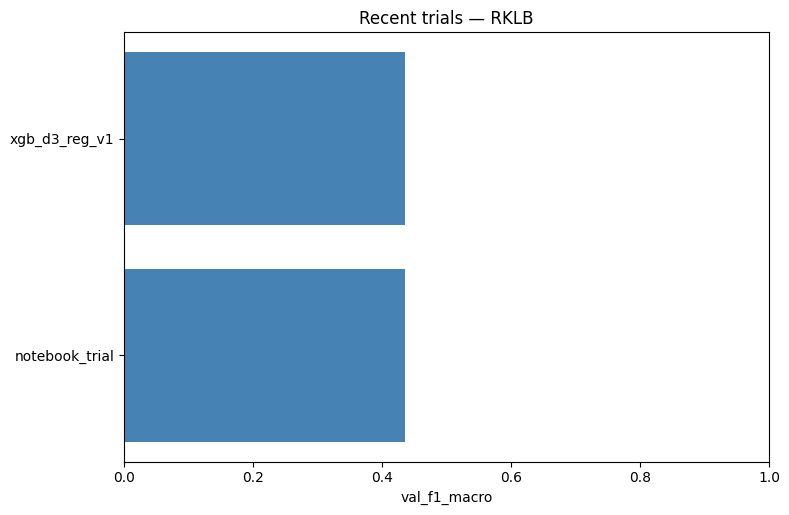

In [ ]:
# Chart: prefer val_f1_macro (better for imbalanced labels), fall back to val_accuracy
import matplotlib.pyplot as plt

if log_path.is_file() and len(trials):
    plot_df = trials.copy()
    metric_col = "val_f1_macro" if "val_f1_macro" in plot_df.columns else "val_accuracy"
    plot_df = plot_df.dropna(subset=[metric_col])
    label_col = "train_experiment_name" if "train_experiment_name" in plot_df.columns else "run_id"
    plot_df["label"] = plot_df[label_col].fillna(plot_df["run_id"]).astype(str)
    plot_df = plot_df.sort_values(metric_col, ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df[metric_col], color="steelblue")
    ax.set_xlabel(metric_col)
    ax.set_title(f"Recent trials — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot yet.")

In [ ]:
# Per-class val metrics for the latest run (or the one you just trained)

def load_latest_metrics(symbol: str, artifacts_dir: str = "artifacts") -> tuple[Path, dict]:
    sym_dir = REPO_ROOT / artifacts_dir / symbol.upper()
    if not sym_dir.is_dir():
        raise FileNotFoundError(sym_dir)
    runs = sorted(p for p in sym_dir.iterdir() if p.is_dir() and (p / "metrics.json").is_file())
    if not runs:
        raise FileNotFoundError("No runs with metrics.json")
    latest = runs[-1]
    return latest, json.loads((latest / "metrics.json").read_text(encoding="utf-8"))

run_dir = last_run_dir if last_run_dir is not None else load_latest_metrics(cfg.symbol)[0]
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
report = metrics.get("classification_report_val", {})
rows = []
for name, stats in report.items():
    if isinstance(stats, dict) and "f1-score" in stats:
        rows.append({"class": name, **stats})
if rows:
    display(pd.DataFrame(rows).set_index("class")[["precision", "recall", "f1-score", "support"]])
    print("Run:", run_dir.name)
else:
    print("No classification_report_val in metrics.json")

,precision,recall,f1-score,support
class,,,,
stop_loss,0.893048,0.590106,0.710638,283.0
take_profit,0.285714,1.000000,0.444444,22.0
vertical,0.128788,0.186813,0.152466,91.0
macro avg,0.435850,0.592306,0.435850,396.0
weighted avg,0.683682,0.520202,0.567583,396.0


Run: 20260620T185408_282826Z
